**source**='https://www.kaggle.com/datasets/wenruliu/adult-income-dataset'

The Kaggle version contains 15 columns: 14 input attributes + 1 target (income), with the target divided into <=50K and >50K

# objectives

Build a machine-learning system that predicts whether a person's annual income is:

<= 50K
> 50K

based on demographic, educational, employment and financial attributes.

In [90]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import joblib

# Load dataset

In [91]:
df = pd.read_csv(r"C:\Users\victus\Downloads\archive (6)\adult.csv")
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [93]:
df.sample(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
4269,42,Private,46019,Some-college,10,Married-civ-spouse,Craft-repair,Husband,Amer-Indian-Eskimo,Male,5178,0,50,United-States,>50K
942,24,Private,126822,HS-grad,9,Never-married,Adm-clerical,Unmarried,White,Female,0,0,45,United-States,<=50K
42034,32,Private,258406,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,0,72,Mexico,<=50K
33227,62,Private,109190,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,15024,0,40,United-States,>50K
9499,33,Self-emp-not-inc,245173,Assoc-acdm,12,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K
35979,43,Local-gov,143046,Some-college,10,Divorced,Other-service,Unmarried,White,Female,0,0,20,United-States,<=50K
4668,18,?,211459,HS-grad,9,Never-married,?,Own-child,White,Male,0,0,30,United-States,<=50K
7207,26,Private,143062,Some-college,10,Divorced,Adm-clerical,Own-child,White,Female,0,0,40,United-States,<=50K
18040,19,Private,197384,Some-college,10,Never-married,Other-service,Own-child,White,Female,0,0,10,United-States,<=50K
38393,28,Private,206088,Bachelors,13,Never-married,Sales,Not-in-family,White,Female,0,0,40,United-States,<=50K


In [94]:
df.shape

(48842, 15)

In [95]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [96]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [97]:
df["workclass"].value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

**Clean column names**

In [98]:
df.columns = df.columns.str.strip()

**Remove spaces from values**

In [99]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

**Rename columns**

In [100]:
df = df.rename(columns={
    "education-num": "education_num",
    "marital-status": "marital_status",
    "capital-gain": "capital_gain",
    "capital-loss": "capital_loss",
    "hours-per-week": "hours_per_week",
    "native-country": "native_country"
})

In [101]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital_status', 'occupation', 'relationship', 'race', 'gender',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [102]:
df.describe(include="object").T

,count,unique,top,freq
workclass,48842,9,Private,33906
education,48842,16,HS-grad,15784
marital_status,48842,7,Married-civ-spouse,22379
occupation,48842,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
gender,48842,2,Male,32650
native_country,48842,42,United-States,43832
income,48842,2,<=50K,37155


**check missing values**

In [103]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital_status     0
occupation         0
relationship       0
race               0
gender             0
capital_gain       0
capital_loss       0
hours_per_week     0
native_country     0
income             0
dtype: int64

**? also represents a null value . so that we convert it to nan i.e. actuall null values**

In [104]:
(df == "?").sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital_status        0
occupation         2809
relationship          0
race                  0
gender                0
capital_gain          0
capital_loss          0
hours_per_week        0
native_country      857
income                0
dtype: int64

In [105]:
df = df.replace("?", np.nan)

In [106]:
df.isnull().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital_status        0
occupation         2809
relationship          0
race                  0
gender                0
capital_gain          0
capital_loss          0
hours_per_week        0
native_country      857
income                0
dtype: int64

In [107]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": df.isnull().mean() * 100
})

missing.sort_values("Percentage", ascending=False)

,Missing,Percentage
occupation,2809,5.751198
workclass,2799,5.730724
native_country,857,1.754637
fnlwgt,0,0.000000
education,0,0.000000
educational-num,0,0.000000
age,0,0.000000
marital_status,0,0.000000
relationship,0,0.000000
gender,0,0.000000


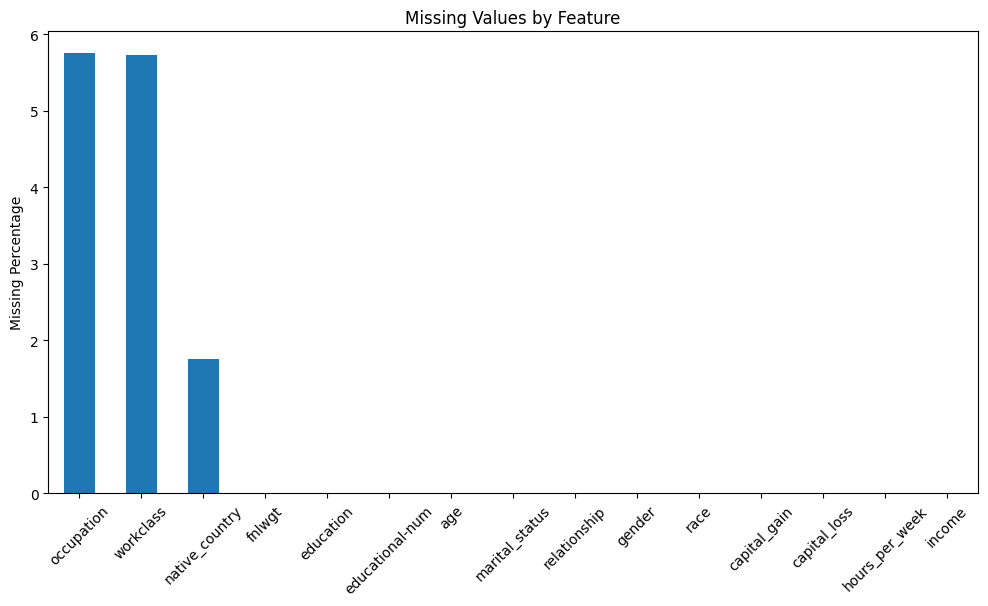

In [108]:
plt.figure(figsize=(12,6))

missing["Percentage"].sort_values(ascending=False).plot(kind="bar")

plt.ylabel("Missing Percentage")
plt.title("Missing Values by Feature")
plt.xticks(rotation=45)
plt.show()

The missing-value analysis shows that missing observations are primarily concentrated in categorical attributes such as workclass and occupation. Since these records still contain useful information in other features, removing the entire rows would result in unnecessary data loss. Therefore, categorical missing values should be imputed rather than dropping the observations.

**check duplicated values and drop duplicates**

In [109]:
df.duplicated().sum()

np.int64(52)

In [110]:
df[df.duplicated()].head()

,age,workclass,fnlwgt,education,educational-num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income
864,24,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
11189,37,Private,52870,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K
11212,29,Private,36440,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
13848,30,Private,180317,Assoc-voc,11,Divorced,Machine-op-inspct,Not-in-family,White,Male,0,0,40,United-States,<=50K
15960,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K


In [111]:
df = df.drop_duplicates().reset_index(drop=True)

In [112]:
df.shape

(48790, 15)

In [113]:
df.duplicated().sum()

np.int64(0)

**analyze target column**

In [114]:
df["income"].value_counts()

income
<=50K    37109
>50K     11681
Name: count, dtype: int64

In [115]:
df["income"].value_counts(normalize=True) * 100

income
<=50K    76.058619
>50K     23.941381
Name: proportion, dtype: float64

**as we can see the target column is imbalanced with percentage around 75 to 25**

 # Univariate analysis of different columns

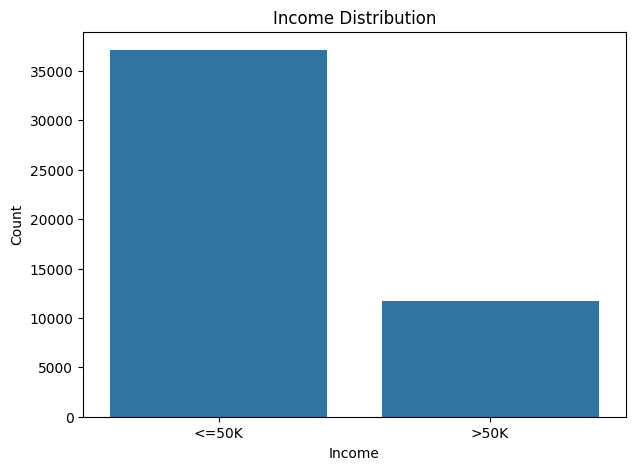

In [116]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="income")

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

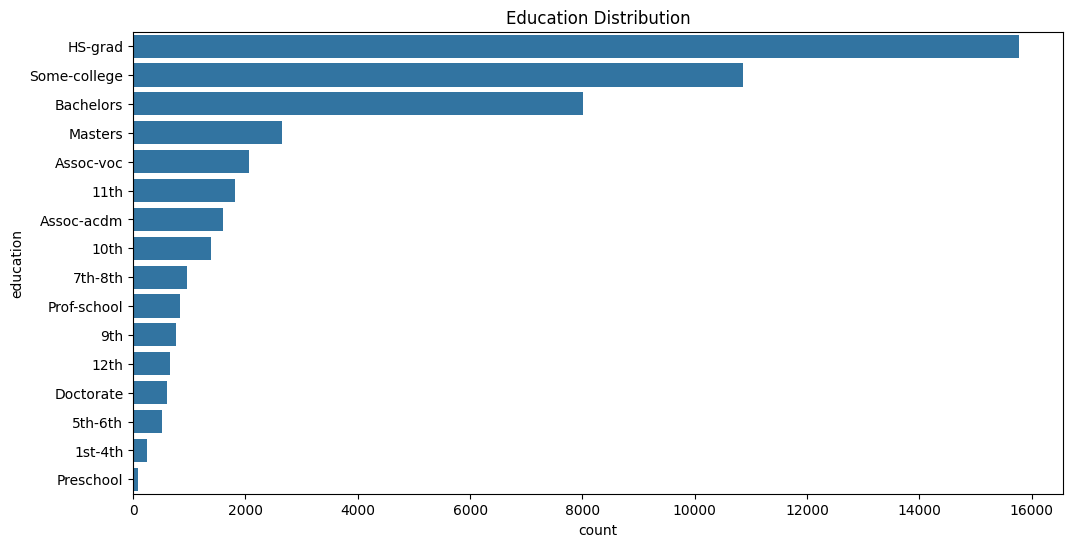

In [117]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="education",
    order=df["education"].value_counts().index
)

plt.title("Education Distribution")
plt.show()

The education distribution is concentrated mainly around high-school graduates, individuals with some college education, and bachelor's degree holders. Very low education categories contain relatively few observations. This uneven distribution should be considered when interpreting income patterns across education levels.

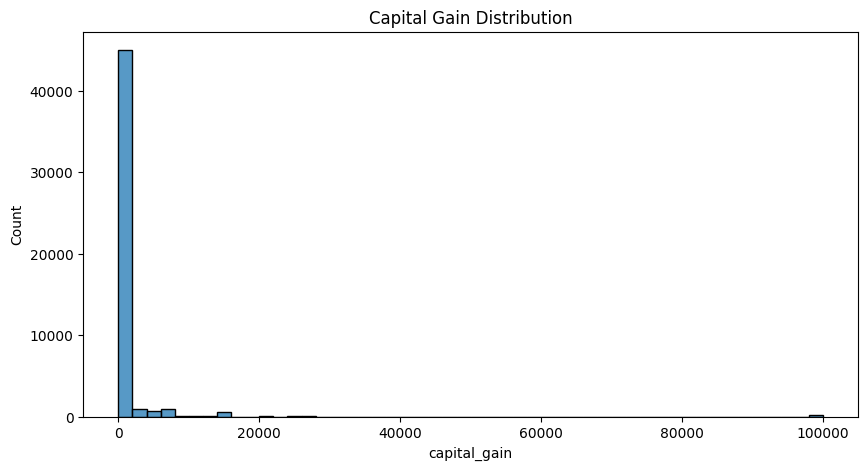

In [118]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="capital_gain",
    bins=50
)

plt.title("Capital Gain Distribution")
plt.show()

Capital gain is highly right-skewed. The median and third quartile are both zero, indicating that most observations have no capital gain, while a small number of observations have very large values, with a maximum of 99,999. Therefore, capital gain contains potentially important information but requires careful treatment because of its highly skewed distribution

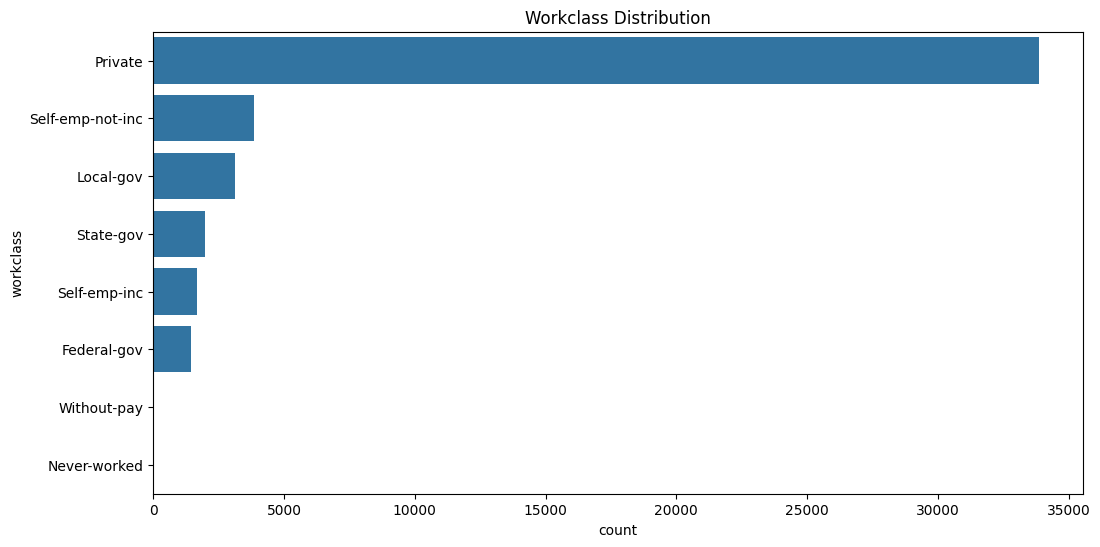

In [119]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="workclass",
    order=df["workclass"].value_counts().index
)

plt.title("Workclass Distribution")
plt.show()

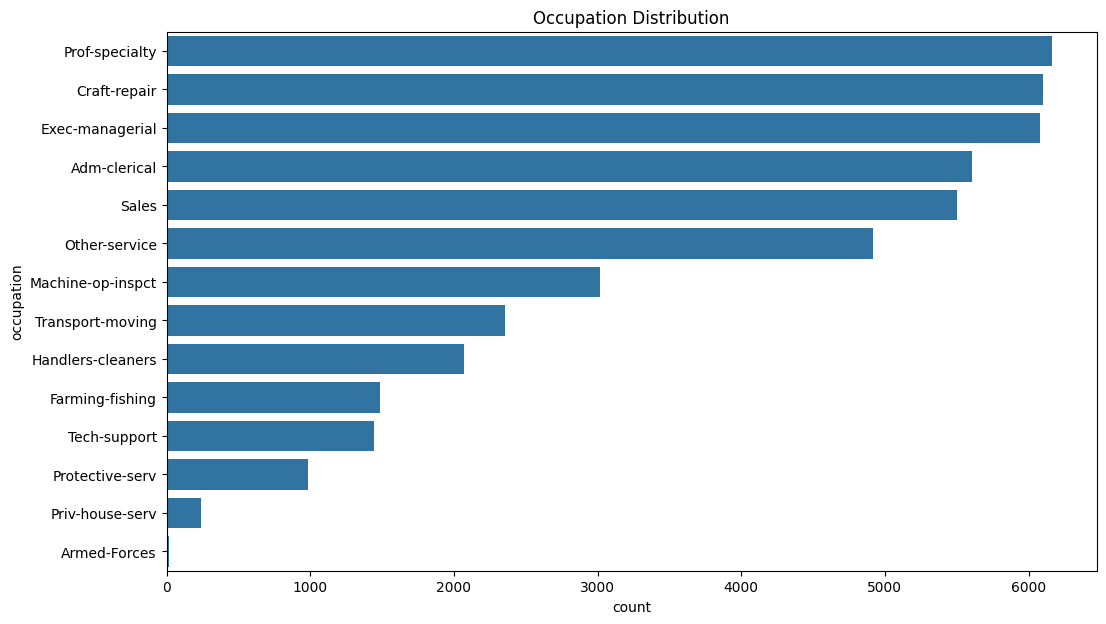

In [120]:
plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y="occupation",
    order=df["occupation"].value_counts().index
)

plt.title("Occupation Distribution")
plt.show()

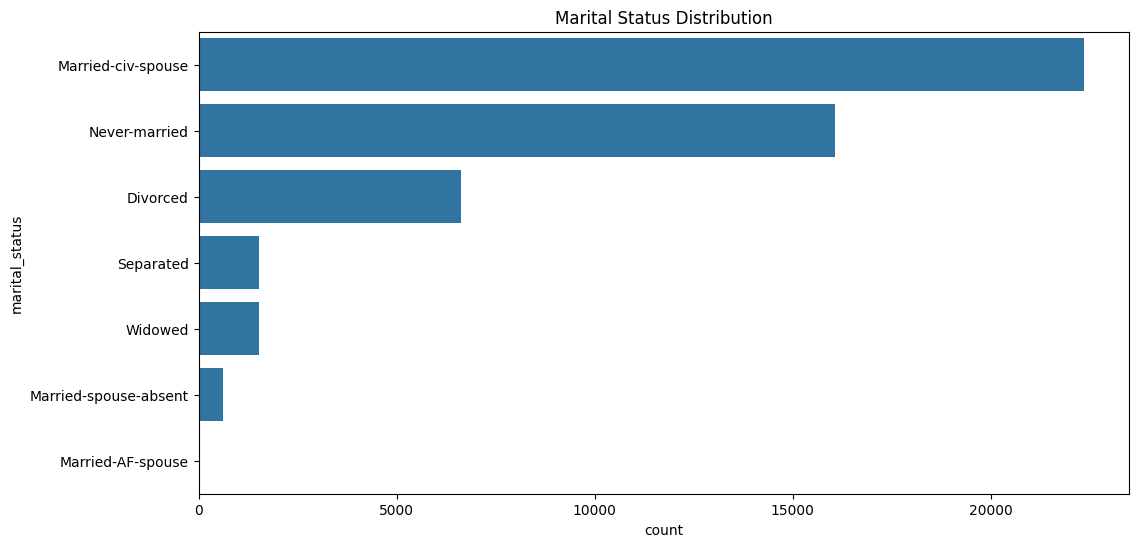

In [121]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="marital_status",
    order=df["marital_status"].value_counts().index
)

plt.title("Marital Status Distribution")
plt.show()

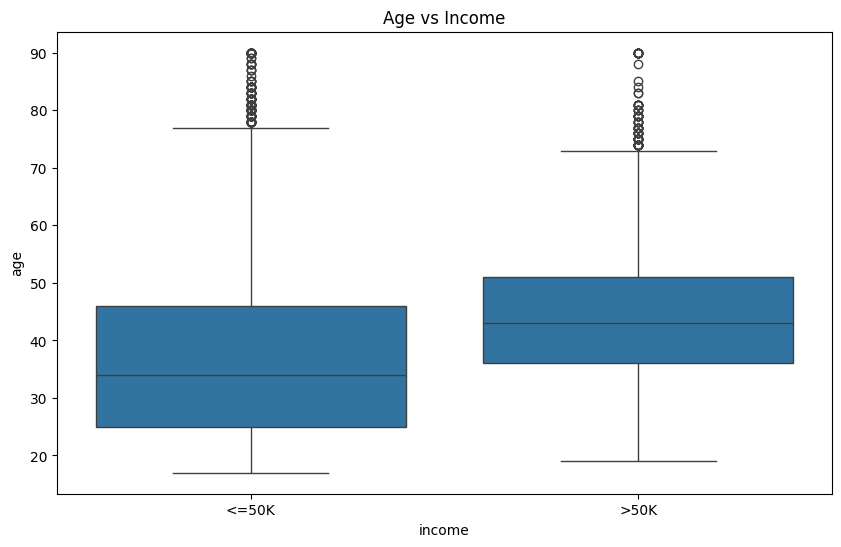

In [122]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="income",
    y="age"
)

plt.title("Age vs Income")
plt.show()

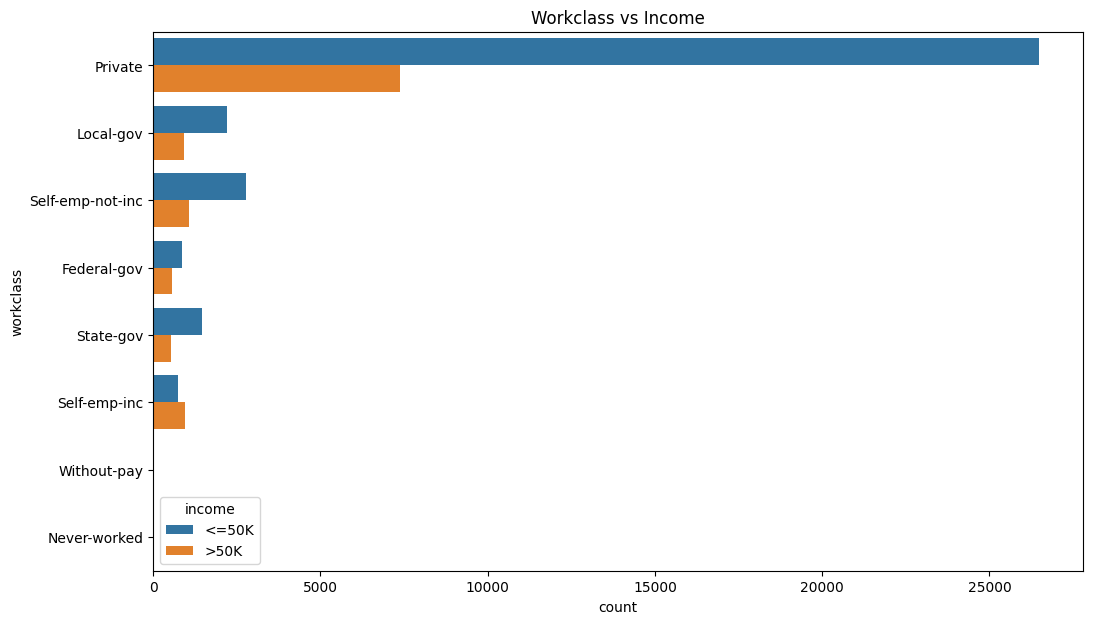

In [123]:
plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y="workclass",
    hue="income"
)

plt.title("Workclass vs Income")
plt.show()

The workclass-income plot shows that both income classes occur across most workclass categories. The private sector contains the largest absolute number of observations from both income groups because it is also the largest workclass category

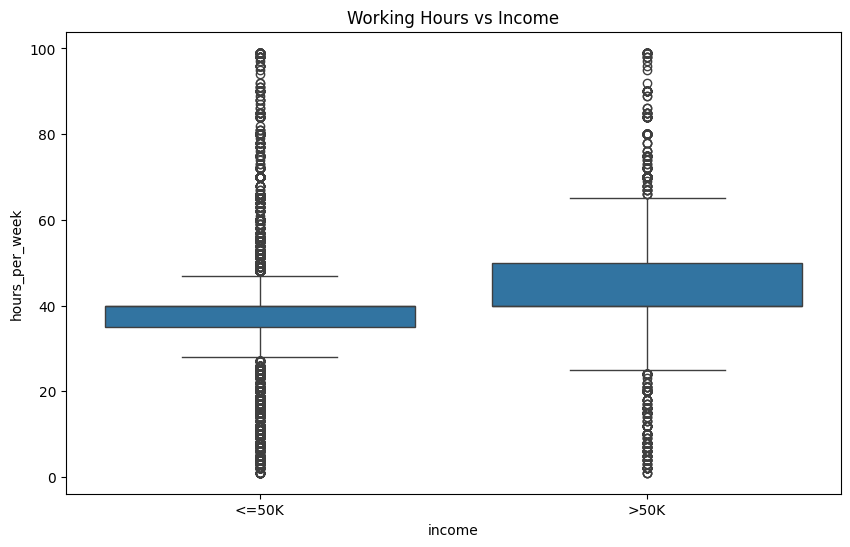

In [124]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="income",
    y="hours_per_week"
)

plt.title("Working Hours vs Income")
plt.show()

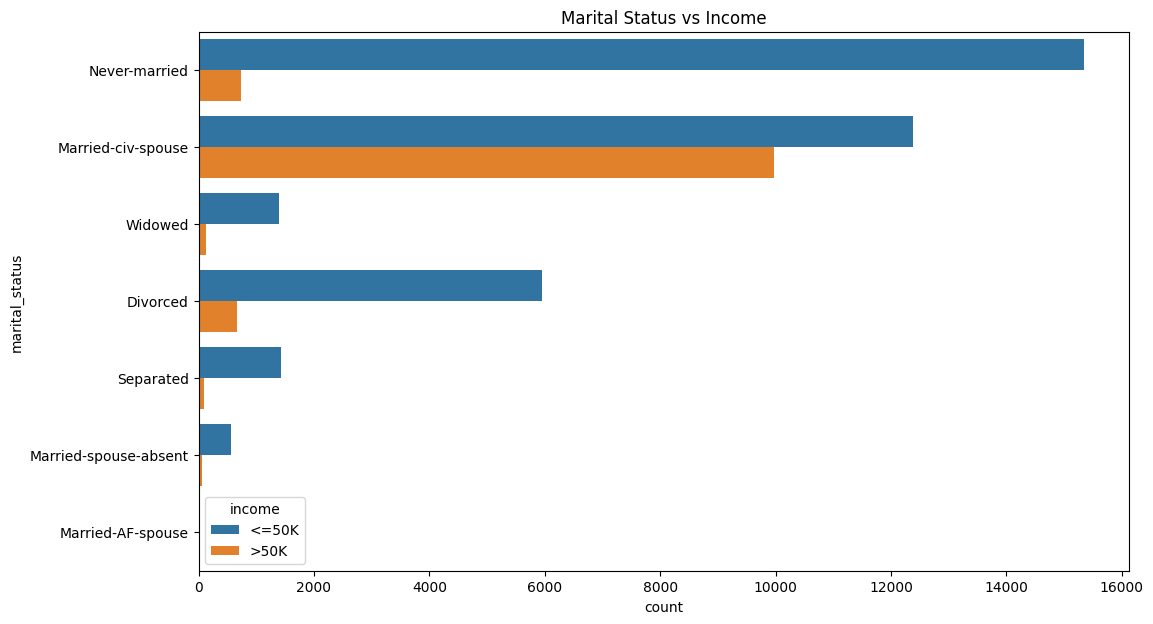

In [125]:
plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y="marital_status",
    hue="income"
)

plt.title("Marital Status vs Income")
plt.show()

In [126]:
education_income = pd.crosstab(
    df["education"],
    df["income"],
    normalize="index"
) * 100

education_income

income,<=50K,>50K
education,,
10th,93.736501,6.263499
11th,94.922737,5.077263
12th,92.671756,7.328244
1st-4th,96.734694,3.265306
5th-6th,94.674556,5.325444
7th-8th,93.501048,6.498952
9th,94.576720,5.423280
Assoc-acdm,74.203623,25.796377
Assoc-voc,74.660194,25.339806


Education shows a strong association with income class. The proportion of individuals earning >50K generally increases as education level increases. For example, the >50K proportion is 15.86% among HS graduates, 41.32% among bachelor's degree holders, 54.93% among master's degree holders, and above 70% among professional-school and doctorate group

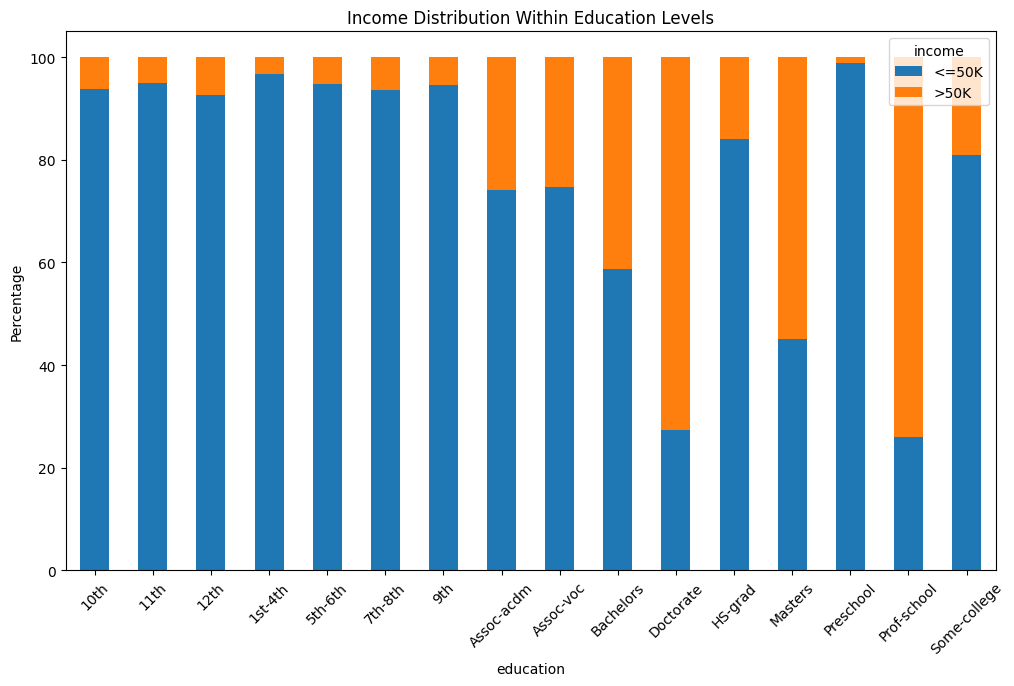

In [127]:
education_income.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7)
)

plt.ylabel("Percentage")
plt.title("Income Distribution Within Education Levels")
plt.xticks(rotation=45)

plt.show()

**covert income class to 0 and 1**

In [128]:
df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [129]:
df["income"].value_counts()

income
0    37109
1    11681
Name: count, dtype: int64

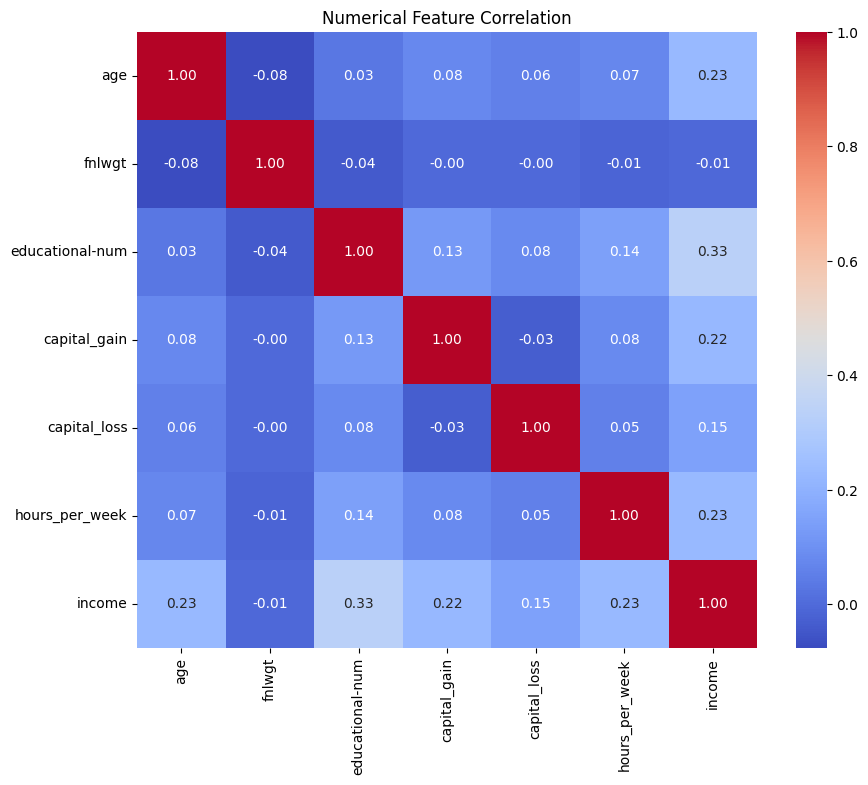

In [130]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Feature Correlation")
plt.show()

**seperate x and y**

In [131]:
X = df.drop(
    "income",
    axis=1
)

y = df["income"]

**see numeric columns**

In [132]:
numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numeric_columns

['age',
 'fnlwgt',
 'educational-num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

**see categorical columns**

In [133]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_columns

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'gender',
 'native_country']

In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [135]:
print(
    y_train.value_counts(normalize=True) * 100
)

income
0    76.058106
1    23.941894
Name: proportion, dtype: float64


In [136]:
print(
    y_test.value_counts(normalize=True) * 100
)

income
0    76.060668
1    23.939332
Name: proportion, dtype: float64


In [137]:
numeric_medians = X_train[
    numeric_columns
].median()

numeric_medians

age                    37.0
fnlwgt             178253.0
educational-num        10.0
capital_gain            0.0
capital_loss            0.0
hours_per_week         40.0
dtype: float64

In [138]:
X_train[numeric_columns] = X_train[
    numeric_columns
].fillna(numeric_medians)

In [139]:
X_test[numeric_columns] = X_test[
    numeric_columns
].fillna(numeric_medians)

In [140]:
categorical_modes = X_train[
    categorical_columns
].mode().iloc[0]

categorical_modes

workclass                    Private
education                    HS-grad
marital_status    Married-civ-spouse
occupation            Prof-specialty
relationship                 Husband
race                           White
gender                          Male
native_country         United-States
Name: 0, dtype: object

In [141]:
X_train[categorical_columns] = X_train[
    categorical_columns
].fillna(categorical_modes)

In [142]:
X_test[categorical_columns] = X_test[
    categorical_columns
].fillna(categorical_modes)

In [143]:
X_train.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital_status     0
occupation         0
relationship       0
race               0
gender             0
capital_gain       0
capital_loss       0
hours_per_week     0
native_country     0
dtype: int64

In [144]:
X_test.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital_status     0
occupation         0
relationship       0
race               0
gender             0
capital_gain       0
capital_loss       0
hours_per_week     0
native_country     0
dtype: int64

In [145]:
print(
    "Training missing values:",
    X_train.isnull().sum().sum()
)

print(
    "Testing missing values:",
    X_test.isnull().sum().sum()
)

Training missing values: 0
Testing missing values: 0


In [146]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [147]:
encoder.fit(
    X_train[categorical_columns]
)

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [148]:
X_train_cat = encoder.transform(
    X_train[categorical_columns]
)

In [149]:
X_test_cat = encoder.transform(
    X_test[categorical_columns]
)

In [150]:
encoded_columns = encoder.get_feature_names_out(
    categorical_columns
)

encoded_columns

array(['workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay', 'education_10th',
       'education_11th', 'education_12th', 'education_1st-4th',
       'education_5th-6th', 'education_7th-8th', 'education_9th',
       'education_Assoc-acdm', 'education_Assoc-voc',
       'education_Bachelors', 'education_Doctorate', 'education_HS-grad',
       'education_Masters', 'education_Preschool',
       'education_Prof-school', 'education_Some-college',
       'marital_status_Divorced', 'marital_status_Married-AF-spouse',
       'marital_status_Married-civ-spouse',
       'marital_status_Married-spouse-absent',
       'marital_status_Never-married', 'marital_status_Separated',
       'marital_status_Widowed', 'occupation_Adm-clerical',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'o

In [151]:
X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoded_columns,
    index=X_train.index
)

In [152]:
X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=encoded_columns,
    index=X_test.index
)

In [153]:
X_train_num = X_train[
    numeric_columns
].copy()

X_test_num = X_test[
    numeric_columns
].copy()

In [154]:
X_train_encoded = pd.concat(
    [
        
        X_train_num,
        X_train_cat
    ],
    axis=1
)
X_test_encoded = pd.concat(
    [
        X_test_num,
        X_test_cat
    ],
    axis=1
)


In [155]:
X_train_encoded.head()

,age,fnlwgt,educational-num,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
13113,44,460259,13,0,0,50,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12054,22,125010,13,0,0,20,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
41025,29,188909,13,0,0,42,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
25013,22,134181,9,0,0,50,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4129,50,240374,14,0,0,50,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [156]:
X_train_encoded.shape

(39032, 105)

In [157]:
print(
    "Original features:",
    X_train.shape[1]
)

print(
    "Encoded features:",
    X_train_encoded.shape[1]
)

Original features: 14
Encoded features: 105


In [158]:
X_train_encoded.dtypes.value_counts()

float64    99
int64       6
Name: count, dtype: int64

In [159]:
scaler = StandardScaler()

In [160]:
X_train_encoded[numeric_columns] = scaler.fit_transform(
    X_train_encoded[numeric_columns]
)
X_test_encoded[numeric_columns] = scaler.transform(
    X_test_encoded[numeric_columns]
)

In [161]:
X_train_encoded[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,39032.0,2.017015e-16,1.000013,-1.579912,-0.776950,-0.119981,0.682981,3.748836
fnlwgt,39032.0,2.257309e-17,1.000013,-1.677784,-0.680521,-0.108666,0.451183,12.296823
educational-num,39032.0,3.195731e-16,1.000013,-3.537377,-0.419253,-0.029488,0.750043,2.309105
capital_gain,39032.0,2.184493e-17,1.000013,-0.144213,-0.144213,-0.144213,-0.144213,13.085766
capital_loss,39032.0,8.210053e-17,1.000013,-0.219158,-0.219158,-0.219158,-0.219158,10.512438
hours_per_week,39032.0,-1.117732e-16,1.000013,-3.180384,-0.033574,-0.033574,0.369864,4.726986


In [162]:
print("Training class counts:")
print(y_train.value_counts())

print("\nTraining percentages:")
print(
    y_train.value_counts(
        normalize=True
    ) * 100
)

Training class counts:
income
0    29687
1     9345
Name: count, dtype: int64

Training percentages:
income
0    76.058106
1    23.941894
Name: proportion, dtype: float64


In [163]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_balanced.fit(
    X_train_encoded,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [164]:
# Predictions
y_pred_balanced = rf_balanced.predict(X_test_encoded)

# Probability predictions
y_prob_balanced = rf_balanced.predict_proba(X_test_encoded)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred_balanced)
precision = precision_score(y_test, y_pred_balanced)
recall = recall_score(y_test, y_pred_balanced)
f1 = f1_score(y_test, y_pred_balanced)
roc_auc = roc_auc_score(y_test, y_prob_balanced)

print("Balanced Random Forest Performance")
print("=" * 45)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Balanced Random Forest Performance
Accuracy  : 0.8522
Precision : 0.7198
Recall    : 0.6267
F1 Score  : 0.6700
ROC-AUC   : 0.9016


In [165]:
print("Classification Report")
print("=" * 45)

print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=["<=50K", ">50K"]
    )
)

Classification Report
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      7422
        >50K       0.72      0.63      0.67      2336

    accuracy                           0.85      9758
   macro avg       0.80      0.77      0.79      9758
weighted avg       0.85      0.85      0.85      9758



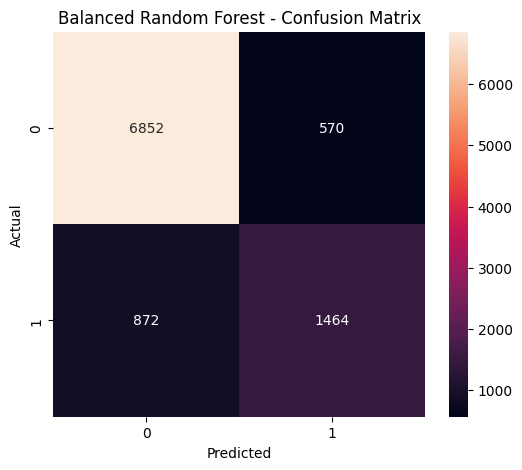

In [166]:
cm = confusion_matrix(
    y_test,
    y_pred_balanced
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Balanced Random Forest - Confusion Matrix")

plt.show()

In [169]:
import os
os.makedirs("adult_income_model", exist_ok=True)

# Save trained model
joblib.dump(
    rf_balanced,
    "adult_income_model/random_forest_balanced.pkl"
)

# Save OneHotEncoder
joblib.dump(
    encoder,
    "adult_income_model/onehot_encoder.pkl"
)

# Save StandardScaler
joblib.dump(
    scaler,
    "adult_income_model/scaler.pkl"
)

# Save feature information
joblib.dump(
    numeric_columns,
    "adult_income_model/numeric_columns.pkl"
)

joblib.dump(
    categorical_columns,
    "adult_income_model/categorical_columns.pkl"
)

# Save encoded feature names
joblib.dump(
    encoded_columns,
    "adult_income_model/encoded_columns.pkl"
)
joblib.dump(
    numeric_medians,
    "adult_income_model/numeric_medians.pkl"
)
joblib.dump(
    numeric_medians,
    "adult_income_model/numeric_medians.pkl"
)
joblib.dump(
    categorical_modes,
    "adult_income_model/categorical_modes.pkl"
)

print("All model components saved successfully.")

All model components saved successfully.


In [171]:
import joblib

training_feature_order = X_train_encoded.columns.tolist()

joblib.dump(
    training_feature_order,
    "adult_income_model/training_feature_order.pkl"
)

print("Training feature order saved successfully.")

Training feature order saved successfully.


In [172]:
import os

print(os.getcwd())

C:\Users\victus
